# Ice Parameter Plots

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
### helper functions
def melt_normalization(f, phi):
    return 1/(f + (1-phi)*(1-f))

def eq_frac_rw_pref(f,kappa_g):
    """
    prefactor for remaining water after equilibrium fractionation during freezing
    """
    return 1/(f + kappa_g*(1-f))

def eq_frac_mw_pref(phi,kappa_g):
    """
    prefactor for meltwater after equilibrium fractionation during melting
    """

    return 1/(1+phi*(kappa_g-1))

### prefactor functions for different sea ice histories

def pref_eqfrac_freeze_nofrac_melt(f, phi, kappa_g):
    """
    equilibrium fractionation durig freezing, no fractionation during melting
    f: remaining water fraction [0,1]
    phi: remaining ice fraction [0,1]
    """
    p_1 = melt_normalization(f, phi)
    p_2 = eq_frac_rw_pref(f,kappa_g)
    p_3 = f + kappa_g*(1-f)*(1-phi)

    return p_1*p_2*p_3

def pref_eqfrac_freeze_eqfrac_melt(f, phi, kappa_g):
    """
    equilibrium fractionation during freezing and melting
    f: remaining water fraction [0,1]
    phi: remaining ice fraction [0,1]
    """
    p_1 = melt_normalization(f,phi)
    p_2 = eq_frac_rw_pref(f,kappa_g)
    p_3 = f + kappa_g*(1-f)*(1-phi)*eq_frac_mw_pref(phi,kappa_g)

    return p_1*p_2*p_3

def pref_Rayfrac_freeze_nofrac_melt(f, phi, kappa_g):
    """
    Rayleigh fractionation during freezing, no fractionation during melting
    f: remaining water fraction [0,1]
    phi: remaining ice fraction [0,1]
    """
    p_1 = melt_normalization(f,phi)
    p_3 = (f**(kappa_g) + (1-phi)*(1-f**kappa_g))

    return p_1*p_3

def pref_Rayfrac_freeze_eqfrac_melt(f, phi, kappa_g):
    """
    Rayleigh fractionation during freezing, equilibrium fractionation during melting
    f: remaining water fraction [0,1]
    phi: remaining ice fraction [0,1]
    """
    p_1 = melt_normalization(f,phi)
    p_3 = f**(kappa_g) + (1-phi)*(1-f**kappa_g)*eq_frac_mw_pref(phi,kappa_g)

    return p_1*p_3


In [30]:
### Taylored prefactors

def R(f,phi):
    return (1-f)*phi

def pref_Taylor_SWIF(f,phi,kappa_g):
    Lambda = 1-R(f,phi)*(kappa_g-1)
    return Lambda

def pref_Taylor_SWIFT(f,phi,kappa_g):
    Lambda = 1-R(f,phi)*(kappa_g**2-1)
    return Lambda

In [4]:
Fractionation_Coefficients = {'He':1.33, 'Ne':0.83, 'Ar':0.49, 'Kr':0.4, 'Xe':0.5 }

In [64]:
f = np.arange(0,1.1,0.1)
f_Tay = np.arange(0.9,1.1,0.01)
phi = np.arange(0,1.1,0.1)
F,Phi = np.meshgrid(f,phi)
F_Tay,Phi_Tay = np.meshgrid(f_Tay,phi)
He_eqno = pref_eqfrac_freeze_nofrac_melt(F, Phi, Fractionation_Coefficients['He'])
He_eqeq = pref_eqfrac_freeze_eqfrac_melt(F, Phi, Fractionation_Coefficients['He'])
He_Rano = pref_Rayfrac_freeze_nofrac_melt(F, Phi, Fractionation_Coefficients['He'])
He_Raeq = pref_Rayfrac_freeze_eqfrac_melt(F, Phi, Fractionation_Coefficients['He'])

He_SWIF = pref_Taylor_SWIF(F, Phi, Fractionation_Coefficients['He'])
He_SWIFT = pref_Taylor_SWIFT(F, Phi, Fractionation_Coefficients['He'])

He_eqno_Tay = pref_eqfrac_freeze_nofrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['He'])
He_eqeq_Tay = pref_eqfrac_freeze_eqfrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['He'])
He_Rano_Tay = pref_Rayfrac_freeze_nofrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['He'])
He_Raeq_Tay = pref_Rayfrac_freeze_eqfrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['He'])

He_SWIF_Tay = pref_Taylor_SWIF(F_Tay, Phi_Tay, Fractionation_Coefficients['He'])
He_SWIFT_Tay = pref_Taylor_SWIFT(F_Tay, Phi_Tay, Fractionation_Coefficients['He'])

Xe_eqno = pref_eqfrac_freeze_nofrac_melt(F, Phi, Fractionation_Coefficients['Xe'])
Xe_eqeq = pref_eqfrac_freeze_eqfrac_melt(F, Phi, Fractionation_Coefficients['Xe'])
Xe_Rano = pref_Rayfrac_freeze_nofrac_melt(F, Phi, Fractionation_Coefficients['Xe'])
Xe_Raeq = pref_Rayfrac_freeze_eqfrac_melt(F, Phi, Fractionation_Coefficients['Xe'])

Xe_SWIF = pref_Taylor_SWIF(F, Phi, Fractionation_Coefficients['Xe'])
Xe_SWIFT = pref_Taylor_SWIFT(F, Phi, Fractionation_Coefficients['Xe'])

Xe_eqno_Tay = pref_eqfrac_freeze_nofrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['Xe'])
Xe_eqeq_Tay = pref_eqfrac_freeze_eqfrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['Xe'])
Xe_Rano_Tay = pref_Rayfrac_freeze_nofrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['Xe'])
Xe_Raeq_Tay = pref_Rayfrac_freeze_eqfrac_melt(F_Tay, Phi_Tay, Fractionation_Coefficients['Xe'])

Xe_SWIF_Tay = pref_Taylor_SWIF(F_Tay, Phi_Tay, Fractionation_Coefficients['Xe'])
Xe_SWIFT_Tay = pref_Taylor_SWIFT(F_Tay, Phi_Tay, Fractionation_Coefficients['Xe'])

/var/folders/_f/3dyj82zs6fdgtrmzqmjdl0lj9rdqt5/T/ipykernel_12014/4250081108.py:3: RuntimeWarning: divide by zero encountered in divide
  return 1/(f + (1-phi)*(1-f))
/var/folders/_f/3dyj82zs6fdgtrmzqmjdl0lj9rdqt5/T/ipykernel_12014/4250081108.py:30: RuntimeWarning: invalid value encountered in multiply
  return p_1*p_2*p_3
/var/folders/_f/3dyj82zs6fdgtrmzqmjdl0lj9rdqt5/T/ipykernel_12014/4250081108.py:42: RuntimeWarning: invalid value encountered in multiply
  return p_1*p_2*p_3
/var/folders/_f/3dyj82zs6fdgtrmzqmjdl0lj9rdqt5/T/ipykernel_12014/4250081108.py:53: RuntimeWarning: invalid value encountered in multiply
  return p_1*p_3
/var/folders/_f/3dyj82zs6fdgtrmzqmjdl0lj9rdqt5/T/ipykernel_12014/4250081108.py:64: RuntimeWarning: invalid value encountered in multiply
  return p_1*p_3


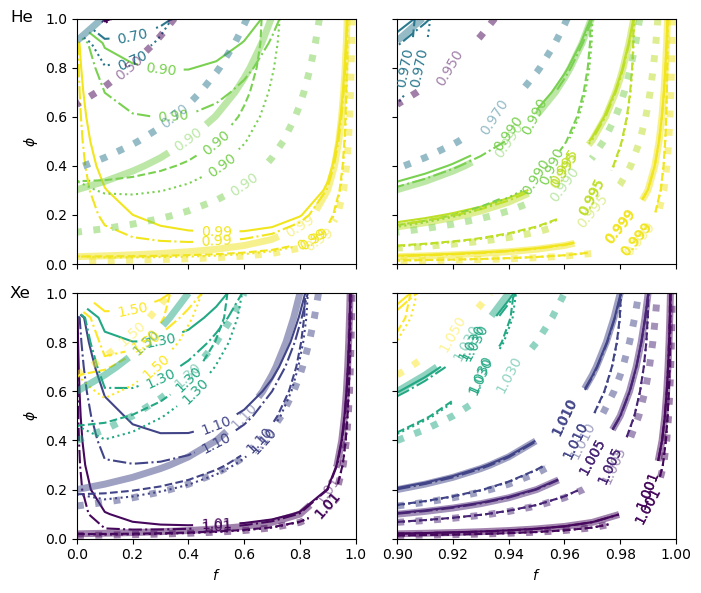

In [104]:
vmin = 0.5
vmax = 1
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
norm2 = mcolors.Normalize(vmin=0.95, vmax=1)
norm3 = mcolors.Normalize(vmin=1.0, vmax=1.5)
norm4 = mcolors.Normalize(vmin=1.0, vmax=1.05)
levels = [0.5, 0.7, 0.9, 0.99]
levels2 = [0.95, 0.97,0.99, 0.995, 0.999]
levels3 = [1.01, 1.1, 1.3, 1.5]
levels4 = [1.001, 1.005, 1.01, 1.03, 1.05]



fig, ax = plt.subplots(2,2, figsize=(7, 6), sharex='col', sharey=True)

CS1 = ax[0,0].contour(F,Phi,He_eqno, norm = norm, levels = levels)
ax[0,0].clabel(CS1, fontsize = 10)
CS2 = ax[0,0].contour(F,Phi,He_eqeq, linestyles = 'dashed', norm = norm, levels = levels)
ax[0,0].clabel(CS2, fontsize = 10)
CS3 = ax[0,0].contour(F,Phi,He_Rano, linestyles = 'dashdot', norm = norm, levels = levels)
ax[0,0].clabel(CS3, fontsize = 10)
CS4 = ax[0,0].contour(F,Phi,He_Raeq, linestyles = 'dotted', norm = norm, levels = levels)
ax[0,0].clabel(CS4, fontsize = 10)
CS5 = ax[0,0].contour(F,Phi,He_SWIF, alpha = 0.5, linewidths = 5, norm = norm, levels = levels)
ax[0,0].clabel(CS5, fontsize = 10)
CS6 = ax[0,0].contour(F,Phi,He_SWIFT, linestyles = 'dotted', alpha = 0.5, linewidths = 5, norm = norm, levels = levels)
ax[0,0].clabel(CS6, fontsize = 10)

CS1T = ax[0,1].contour(F_Tay,Phi_Tay,He_eqno_Tay, norm = norm2, levels = levels2)
ax[0,1].clabel(CS1T, fontsize = 10)
CS2T = ax[0,1].contour(F_Tay,Phi_Tay,He_eqeq_Tay, linestyles = 'dashed', norm = norm2, levels = levels2)
ax[0,1].clabel(CS2T, fontsize = 10)
CS3T = ax[0,1].contour(F_Tay,Phi_Tay,He_Rano_Tay, linestyles = 'dashdot', norm = norm2, levels = levels2)
ax[0,1].clabel(CS3T, fontsize = 10)
CS4T = ax[0,1].contour(F_Tay,Phi_Tay,He_Raeq_Tay, linestyles = 'dotted', norm = norm2, levels = levels2)
ax[0,1].clabel(CS4T, fontsize = 10)
CS5T = ax[0,1].contour(F_Tay,Phi_Tay,He_SWIF_Tay, alpha = 0.5, linewidths = 5, norm = norm2, levels = levels2)
ax[0,1].clabel(CS5T, fontsize = 10)
CS6T = ax[0,1].contour(F_Tay,Phi_Tay,He_SWIFT_Tay, linestyles = 'dotted', alpha = 0.5, linewidths = 5, norm = norm2, levels = levels2)
ax[0,1].clabel(CS6T, fontsize = 10)

DS1 = ax[1,0].contour(F,Phi,Xe_eqno, norm = norm3, levels = levels3)
ax[1,0].clabel(DS1, fontsize = 10)
DS2 = ax[1,0].contour(F,Phi,Xe_eqeq, linestyles = 'dashed', norm = norm3, levels = levels3)
ax[1,0].clabel(DS2, fontsize = 10)
DS3 = ax[1,0].contour(F,Phi,Xe_Rano, linestyles = 'dashdot', norm = norm3, levels = levels3)
ax[1,0].clabel(DS3, fontsize = 10)
DS4 = ax[1,0].contour(F,Phi,Xe_Raeq, linestyles = 'dotted', norm = norm3, levels = levels3)
ax[1,0].clabel(DS4, fontsize = 10)
DS5 = ax[1,0].contour(F,Phi,Xe_SWIF, alpha = 0.5, linewidths = 5, norm = norm3, levels = levels3)
ax[1,0].clabel(DS5, fontsize = 10)
DS6 = ax[1,0].contour(F,Phi,Xe_SWIFT, linestyles = 'dotted', alpha = 0.5, linewidths = 5, norm = norm3, levels = levels3)
ax[1,0].clabel(DS6, fontsize = 10)

DS1T = ax[1,1].contour(F_Tay,Phi_Tay,Xe_eqno_Tay, norm = norm4, levels = levels4)
ax[1,1].clabel(DS1T, fontsize = 10)
DS2T = ax[1,1].contour(F_Tay,Phi_Tay,Xe_eqeq_Tay, linestyles = 'dashed', norm = norm4, levels = levels4)
ax[1,1].clabel(DS2T, fontsize = 10)
DS3T = ax[1,1].contour(F_Tay,Phi_Tay,Xe_Rano_Tay, linestyles = 'dashdot', norm = norm4, levels = levels4)
ax[1,1].clabel(DS3T, fontsize = 10)
DS4T = ax[1,1].contour(F_Tay,Phi_Tay,Xe_Raeq_Tay, linestyles = 'dotted', norm = norm4, levels = levels4)
ax[1,1].clabel(DS4T, fontsize = 10)
DS5T = ax[1,1].contour(F_Tay,Phi_Tay,Xe_SWIF_Tay, alpha = 0.5, linewidths = 5, norm = norm4, levels = levels4)
ax[1,1].clabel(DS5T, fontsize = 10)
DS6T = ax[1,1].contour(F_Tay,Phi_Tay,Xe_SWIFT_Tay, linestyles = 'dotted', alpha = 0.5, linewidths = 5, norm = norm4, levels = levels4)
ax[1,1].clabel(DS6T, fontsize = 10)

ax[0,1].set_xlim([0.9,1])
ax[1,1].set_xlim([0.9,1])

ax[1,0].set_xlabel('$f$')
ax[1,1].set_xlabel('$f$')

ax[0,0].set_ylabel('$\\phi$')
ax[1,0].set_ylabel('$\\phi$')

# Row labels
fig.text(0.005, 0.98, 'He', fontsize=12, va='top')
fig.text(0.005, 0.52, 'Xe', fontsize=12, va='top')

plt.tight_layout()
plt.savefig('phi_f_plot_He_Xe.png', dpi = 900)

In [93]:
def pref_dynamic(omega, kappa_g):
    return 1/(1+omega*(kappa_g-1)) 

def pref_static_Taylor_SWIF(R, kappa_g):
    return 1- R*(kappa_g-1)

def pref_static_Taylor_SWIFT(R, kappa_g):
    return 1-R*(kappa_g**2-1)

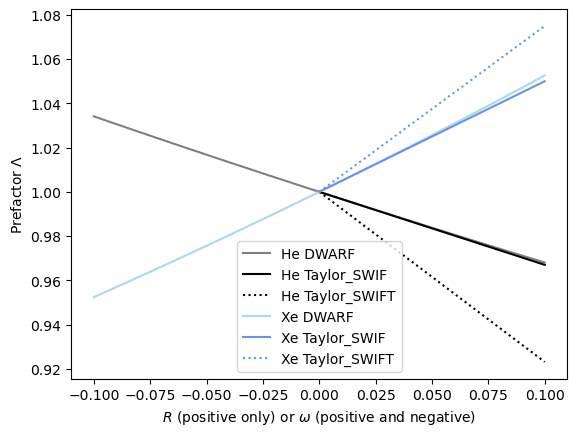

In [105]:
R = np.linspace(0,0.1,100)
omega = np.linspace(-0.1,0.1,100)


plt.plot(omega, pref_dynamic(omega, Fractionation_Coefficients['He']), color = 'gray', label = 'He DWARF')
plt.plot(R, pref_static_Taylor_SWIF(R, Fractionation_Coefficients['He']), color = 'black', label = 'He Taylor_SWIF')
plt.plot(R, pref_static_Taylor_SWIFT(R, Fractionation_Coefficients['He']), color = 'black', ls = ':', label = 'He Taylor_SWIFT')

plt.plot(omega, pref_dynamic(omega, Fractionation_Coefficients['Xe']), color = 'lightblue', label = 'Xe DWARF')
plt.plot(R, pref_static_Taylor_SWIF(R, Fractionation_Coefficients['Xe']), color = 'cornflowerblue', label = 'Xe Taylor_SWIF')
plt.plot(R, pref_static_Taylor_SWIFT(R, Fractionation_Coefficients['Xe']), color = 'cornflowerblue', ls = ':', label = 'Xe Taylor_SWIFT')

plt.legend()

plt.xlabel('$R$ (positive only) or $\\omega$ (positive and negative)')
plt.ylabel('Prefactor $\\Lambda$')

plt.savefig('Lambda_omega_R.png', dpi = 900)